In [3]:
import sys
print(sys.executable)

c:\Users\PMLS\Desktop\Python\clv-prediction\venv\Scripts\python.exe


In [4]:
import pandas as pd

# Load dataset
df = pd.read_excel("../Data/raw/Online Retail.xlsx")

# Basic inspection
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])

In [13]:
df = df[df['Quantity'] > 0]

In [9]:
df = df[df['UnitPrice'] > 0]

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 35.4+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [16]:
df = df.drop_duplicates()

In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [18]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [19]:
df = df[df['Country'] == 'United Kingdom']

In [20]:
df = df[df['Quantity'] < 1000]
df = df[df['UnitPrice'] < 500]

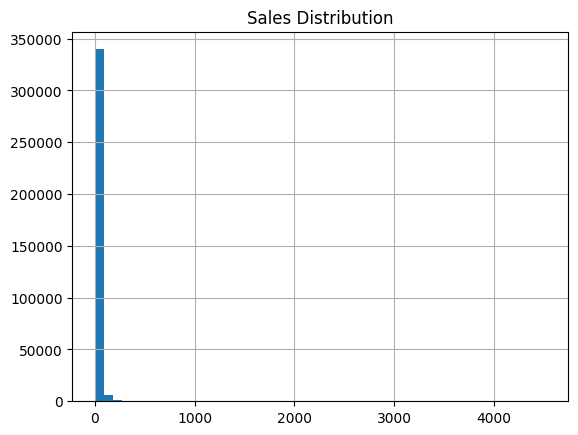

In [21]:
import matplotlib.pyplot as plt

df['TotalPrice'].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

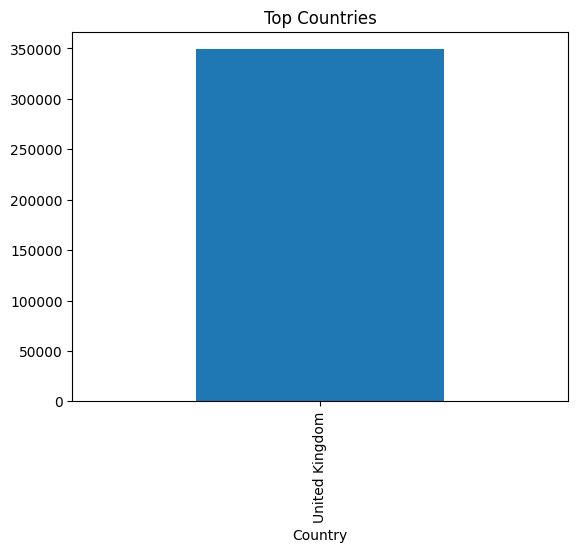

In [22]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

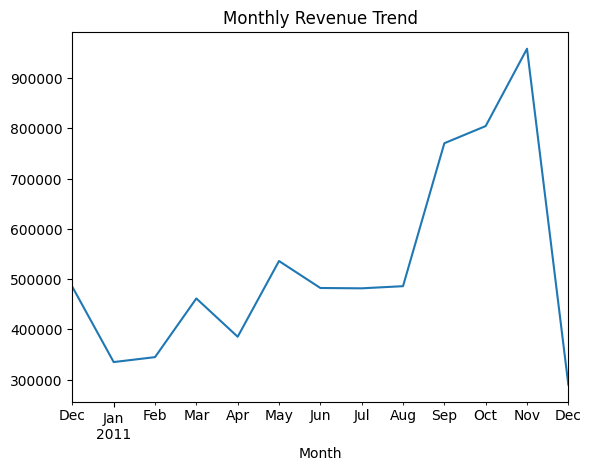

In [23]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

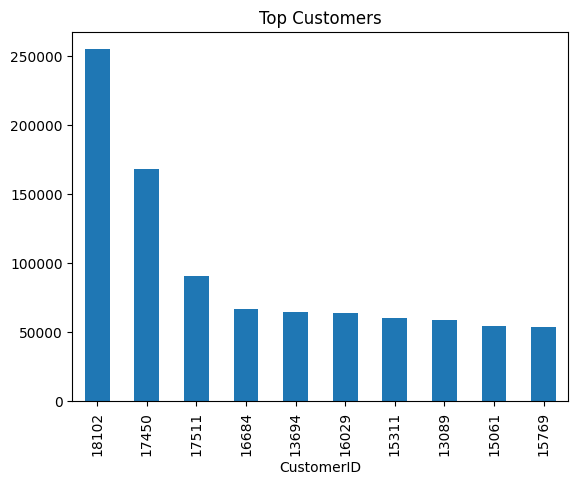

In [24]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers")
plt.show()

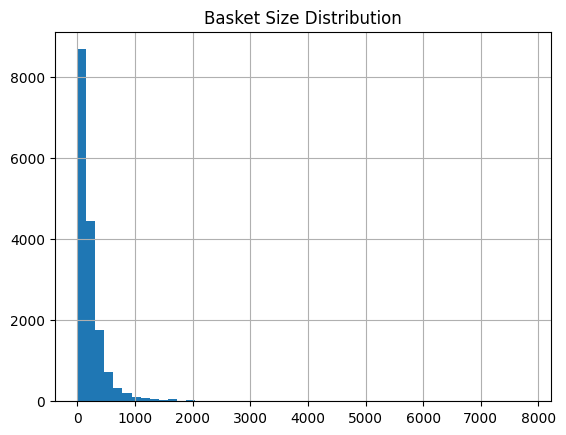

In [25]:
df.groupby('InvoiceNo')['Quantity'].sum().hist(bins=50)
plt.title("Basket Size Distribution")
plt.show()

In [26]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [28]:
df.Country

0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541889    United Kingdom
541890    United Kingdom
541891    United Kingdom
541892    United Kingdom
541893    United Kingdom
Name: Country, Length: 349076, dtype: str

In [33]:
df['Country'].unique


<bound method Series.unique of 0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541889    United Kingdom
541890    United Kingdom
541891    United Kingdom
541892    United Kingdom
541893    United Kingdom
Name: Country, Length: 349076, dtype: str>

Freature Engineering 

In [46]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:49:00')

In [47]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [48]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12747,2,11,4196.01
1,12748,1,208,32202.69
2,12749,4,5,4090.88
3,12820,3,4,942.34
4,12821,214,1,92.72


In [37]:
rfm.head

<bound method NDFrame.head of             Recency  Frequency  Monetary
CustomerID                              
12747             2         11   4196.01
12748             1        208  32202.69
12749             4          5   4090.88
12820             3          4    942.34
12821           214          1     92.72
...             ...        ...       ...
18280           278          1    180.60
18281           181          1     80.82
18282             8          2    178.05
18283             4         16   2045.53
18287            43          3   1837.28

[3911 rows x 3 columns]>

In [49]:
print("Shape:", rfm.shape)
rfm.info()
rfm.describe()

Shape: (3911, 4)
<class 'pandas.DataFrame'>
RangeIndex: 3911 entries, 0 to 3910
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  3911 non-null   int64  
 1   Recency     3911 non-null   int64  
 2   Frequency   3911 non-null   int64  
 3   Monetary    3911 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 122.3 KB


,CustomerID,Recency,Frequency,Monetary
count,3911.000000,3911.000000,3911.000000,3911.000000
mean,15561.327538,92.215290,4.243927,1744.500602
std,1575.428253,99.566262,7.178850,6488.709886
min,12747.000000,1.000000,1.000000,2.900000
25%,14208.500000,18.000000,1.000000,296.090000
50%,15569.000000,51.000000,2.000000,641.920000
75%,16912.500000,143.000000,5.000000,1552.480000
max,18287.000000,374.000000,208.000000,255000.340000


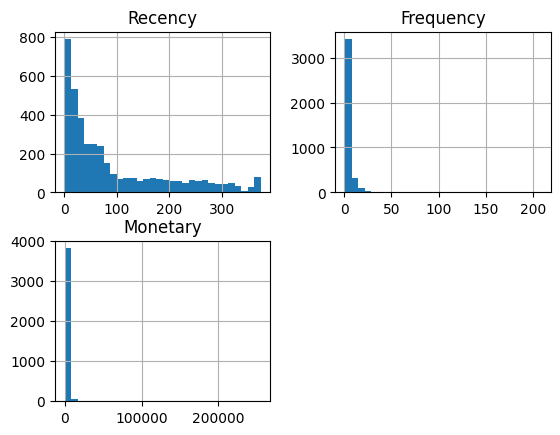

In [39]:
import matplotlib.pyplot as plt

rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=30)
plt.show()

In [50]:
import pandas as pd

# Recency (reverse scoring: lower is better)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1], duplicates='drop')

# Frequency & Monetary (auto bins → then convert)
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, duplicates='drop')

# Convert categorical bins to numeric scores
rfm['F_score'] = rfm['F_score'].cat.codes + 1
rfm['M_score'] = rfm['M_score'].cat.codes + 1

In [51]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12747,2,11,4196.01,5,4,5,545
1,12748,1,208,32202.69,5,4,5,545
2,12749,4,5,4090.88,5,3,5,535
3,12820,3,4,942.34,5,3,4,534
4,12821,214,1,92.72,1,1,1,111


In [52]:
import numpy as np

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

In [53]:
# Missing values
print("Missing values:\n", rfm.isnull().sum())

# Score distribution
print("\nF_score distribution:\n", rfm['F_score'].value_counts())
print("\nM_score distribution:\n", rfm['M_score'].value_counts())

# Correlation
print("\nCorrelation:\n", rfm[['Recency','Frequency','Monetary']].corr())

Missing values:
 CustomerID       0
Recency          0
Frequency        0
Monetary         0
R_score          0
F_score          0
M_score          0
RFM_Score        0
Recency_log      0
Frequency_log    0
Monetary_log     0
dtype: int64

F_score distribution:
 F_score
1    2093
3     725
4     632
2     461
Name: count, dtype: int64

M_score distribution:
 M_score
1    783
5    782
4    782
2    782
3    782
Name: count, dtype: int64

Correlation:
             Recency  Frequency  Monetary
Recency    1.000000  -0.274456 -0.150049
Frequency -0.274456   1.000000  0.568845
Monetary  -0.150049   0.568845  1.000000


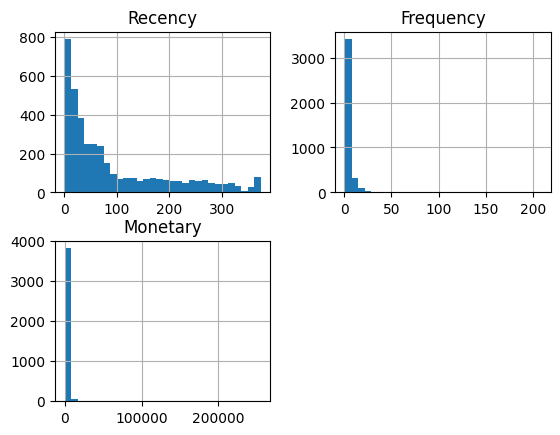

In [54]:
import matplotlib.pyplot as plt

rfm[['Recency','Frequency','Monetary']].hist(bins=30)
plt.show()

In [55]:
rfm.sort_values(by='Monetary', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Recency_log,Frequency_log,Monetary_log
3775,18102,1,60,255000.34,5,4,5,545,0.693147,4.110874,12.449024
3308,17450,8,46,168580.07,5,4,5,545,2.197225,3.850148,12.035172
3350,17511,3,31,91062.38,5,4,5,545,1.386294,3.465736,11.419311
2761,16684,4,28,66653.56,5,4,5,545,1.609438,3.367296,11.107279
618,13694,4,49,64640.74,5,4,5,545,1.609438,3.912023,11.076616
2290,16029,39,61,64074.81,3,4,5,345,3.688879,4.127134,11.067822
1767,15311,1,91,60632.75,5,4,5,545,0.693147,4.521789,11.012607
190,13089,3,97,58762.08,5,4,5,545,1.386294,4.584967,10.981269
1577,15061,4,48,54534.14,5,4,5,545,1.609438,3.891820,10.906601
2105,15769,7,26,54272.72,5,4,5,545,2.079442,3.295837,10.901795


In [56]:
rfm['CLV'] = rfm['Monetary_log']

In [57]:
rfm[['Recency_log','Frequency_log','Monetary_log','CLV']].describe()

,Recency_log,Frequency_log,Monetary_log,CLV
count,3911.000000,3911.000000,3911.000000,3911.000000
mean,3.828334,1.346196,6.528303,6.528303
std,1.339209,0.682366,1.237055,1.237055
min,0.693147,0.693147,1.360977,1.360977
25%,2.944439,0.693147,5.694035,5.694035
50%,3.951244,1.098612,6.466020,6.466020
75%,4.969813,1.791759,7.348253,7.348253
max,5.926926,5.342334,12.449024,12.449024


In [58]:
X = rfm[['Recency_log', 'Frequency_log']]
y = rfm['CLV']

Modeling

In [59]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency_log', 'Frequency_log']]
y = rfm['CLV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(3128, 2) (783, 2)


In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

In [62]:
evaluate(y_test, y_pred_lr, "Linear Regression")


Linear Regression
MAE: 0.5192636467177434
RMSE: 0.6792583382621475
R2: 0.6858758910478613


In [63]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate(y_test, y_pred_rf, "Random Forest")


Random Forest
MAE: 0.5661586852432559
RMSE: 0.7630220825384445
R2: 0.6036256644253073


In [64]:
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['AvgOrderValue_log'] = np.log1p(rfm['AvgOrderValue'])

In [65]:
customer_lifetime = df.groupby('CustomerID')['InvoiceDate'].agg(['min','max'])
customer_lifetime['Lifetime'] = (customer_lifetime['max'] - customer_lifetime['min']).dt.days

rfm = rfm.merge(customer_lifetime['Lifetime'], on='CustomerID')
rfm['Lifetime_log'] = np.log1p(rfm['Lifetime'])

In [66]:
rfm['PurchaseIntensity'] = rfm['Frequency'] / (rfm['Lifetime'] + 1)
rfm['PurchaseIntensity_log'] = np.log1p(rfm['PurchaseIntensity'])

In [73]:
# Features
X = rfm[
    [
        'Recency_log',
        'Frequency_log',
        'Lifetime_log',
        'PurchaseIntensity_log'
    ]
]

y = rfm['CLV']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3128, 4) Test: (783, 4)


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

In [76]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

evaluate(y_test, y_pred_lr, "Linear Regression")


Linear Regression
MAE: 0.5168327340234445
RMSE: 0.6758482055207555
R2: 0.6890220165277317


In [77]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate(y_test, y_pred_rf, "Random Forest")


Random Forest
MAE: 0.5198450304515728
RMSE: 0.6948470044925815
R2: 0.6712924402844744


In [79]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

evaluate(y_test, y_pred_xgb, "XGBoost")


XGBoost
MAE: 0.5240524221514622
RMSE: 0.6893315329152861
R2: 0.6764900788345856


In [80]:
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
}

import pandas as pd
pd.DataFrame(results)

,Model,R2,RMSE
0,Linear Regression,0.689022,0.675848
1,Random Forest,0.671292,0.694847
2,XGBoost,0.676490,0.689332
